---

<div style="background-color: #f8f9fa; padding: 25px; border-radius: 15px; border: 1px solid #e9ecef; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
    <div style="display: flex; align-items: center; gap: 20px;">
        <div style="flex: 1;">
            <h1 style="color: #2c3e50; margin: 0; font-size: 28px;">👨‍💻 Hemant Sharma</h1>
            <p style="color: #3498db; font-size: 18px; margin: 5px 0; font-weight: 600;">Computer Science & Engineering Student | PIET</p>
            <hr style="border: 0; border-top: 2px solid #3498db; width: 50px; margin: 15px 0;">
            <p style="color: #576574; line-height: 1.6; font-size: 15px;">
                I am a <b>CSE Student</b> at Poornima Institute of Engineering and Technology, focused on
                <b>Machine Learning</b> and <b>Artificial Intelligence</b>. This project (Day 2) is a detailed
                exploration into <b>Optimisers, Initialisation, and Regularisation</b>, emphasizing how
                to make Neural Networks smarter and more stable.
            </p>
            <div style="margin-top: 20px;">
                <span style="background: #e1f5fe; color: #039be5; padding: 5px 12px; border-radius: 20px; font-size: 12px; font-weight: bold; margin-right: 5px;">#MachineLearning</span>
                <span style="background: #f3e5f5; color: #8e24aa; padding: 5px 12px; border-radius: 20px; font-size: 12px; font-weight: bold; margin-right: 5px;">#NeuralNetworks</span>
                <span style="background: #e8f5e9; color: #2e7d32; padding: 5px 12px; border-radius: 20px; font-size: 12px; font-weight: bold;">#AIDeveloper</span>
            </div>
        </div>
    </div>
    <div style="margin-top: 20px; border-top: 1px solid #eee; padding-top: 15px; display: flex; gap: 20px;">
        <a href="mailto:artist.hks.dev@gmail.com" style="text-decoration: none; color: #2c3e50; font-size: 14px;">📧 <b>Email:</b> artist.hks.dev@gmail.com</a>
        <a href="https://www.linkedin.com/in/artisthks" target="_blank" style="text-decoration: none; color: #2c3e50; font-size: 14px;">🔗 <b>LinkedIn:</b> artisthks</a>
    </div>
</div>

---

# <p style="color:#2980b9; font-family:sans-serif; text-align:center; font-size:38px; font-weight:bold;">🎓 Day 2 Masterclass: The Science of Learning</p>
### <p style="text-align:center; color:#34495e; font-size:20px;">Optimisation • Initialisation • Regularisation</p>

---

<div style="background-color: #e3f2fd; padding: 20px; border-radius: 10px; border-left: 5px solid #2196f3;">
    <strong>🎯 Today's Goal:</strong> Yesterday we built the "Brain" (Architecture). Today, we teach it <b>HOW to learn</b> faster, smarter, and without memorizing.
</div>

## 🧠 The "Hiking" Framework
We compare our model's training to a hiker descending a foggy mountain:
* **The Path (Optimiser):** How fast & smart do we walk?
* **The Starting Point (Initialisation):** Where on the mountain do we begin?
* **The Memory (Regularisation):** Are we learning the map or just memorizing the rocks?

> ⏱️ **Session Duration:** 1.5 Hours | **Dataset:** Breast Cancer Wisconsin (Clinical Data)

In [12]:
# ── THE TOOLBOX ──────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid") # Making plots look aesthetic

# ── LOADING THE DATA ─────────────────────────────────────────────────────
data = load_breast_cancer()
X, y = data.data, data.target

# ── TRAIN-TEST SPLIT (The 80/20 Rule) ────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'✅ Lab Ready! | Training Samples: {X_train.shape[0]} | Testing Samples: {X_test.shape[0]}')
print(f'🔴 Malignant: {(y==0).sum()} | 🟢 Benign: {(y==1).sum()}')

✅ Lab Ready! | Training Samples: 455 | Testing Samples: 114
🔴 Malignant: 212 | 🟢 Benign: 357


In [13]:
# Analogy: Comparing 100kg with 170cm is confusing. Scaling makes them comparable.
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Visual Proof of Scaling
print(f'📊 Before Scaling (Radius Max): {X_train[:,0].max():.2f}')
print(f'📊 After Scaling (Radius Max) : {X_train_scaled[:,0].max():.2f} (Normalized! ✅)')

📊 Before Scaling (Radius Max): 28.11
📊 After Scaling (Radius Max) : 3.96 (Normalized! ✅)


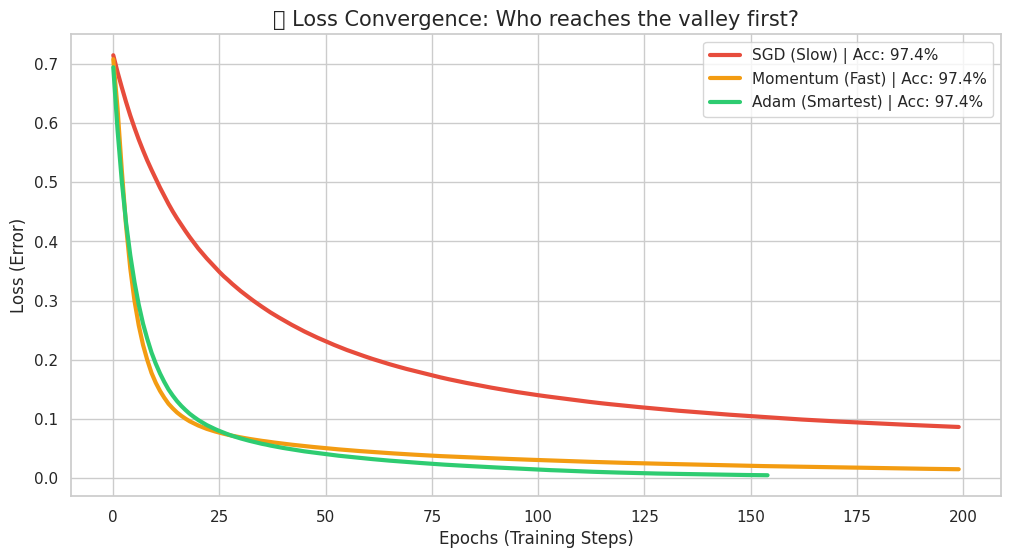

In [14]:
# We are comparing 3 different "Walking Styles" (Optimisers)
results = {}
optimisers = [
    ('SGD (Slow)', 'sgd', 0.01, 0.0, '#e74c3c'),
    ('Momentum (Fast)', 'sgd', 0.01, 0.9, '#f39c12'),
    ('Adam (Smartest)', 'adam', 0.001, 0.0, '#2ecc71')
]

plt.figure(figsize=(12, 6))

for label, solver, lr, mom, col in optimisers:
    model = MLPClassifier(hidden_layer_sizes=(64, 32), solver=solver,
                          momentum=mom, learning_rate_init=lr,
                          max_iter=200, random_state=42).fit(X_train_scaled, y_train)

    acc = accuracy_score(y_test, model.predict(X_test_scaled))
    results[label] = acc
    plt.plot(model.loss_curve_, label=f'{label} | Acc: {acc*100:.1f}%', color=col, lw=3)

plt.title('🏔️ Loss Convergence: Who reaches the valley first?', fontsize=15)
plt.xlabel('Epochs (Training Steps)'); plt.ylabel('Loss (Error)')
plt.legend(); plt.show()

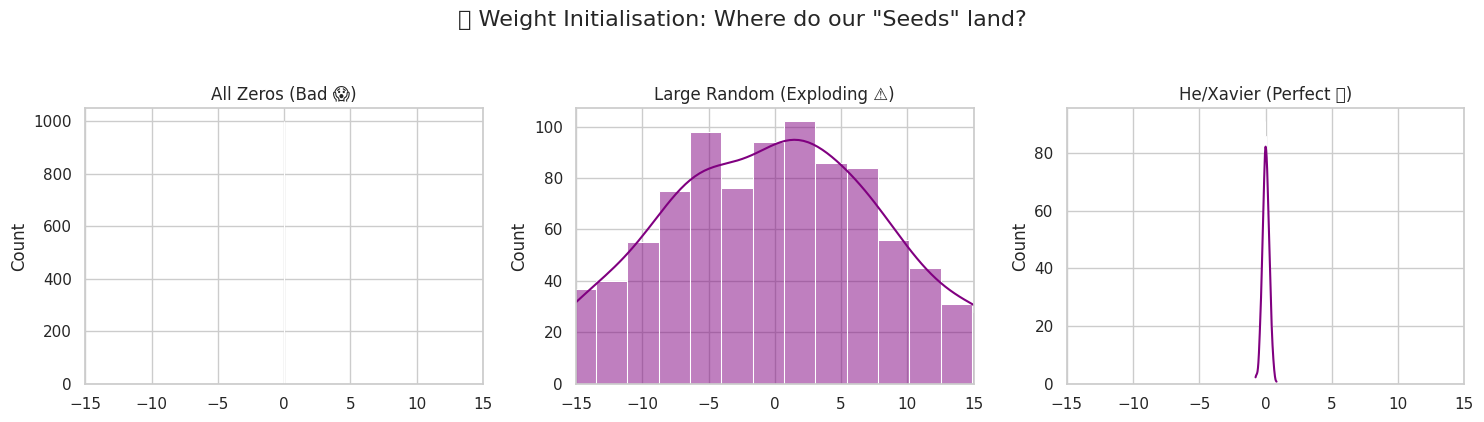

In [15]:
# Analogy: Bad seeds = Dead plants. Bad weights = Dead neurons.
np.random.seed(42)
n = 1000

inits = {
    'All Zeros (Bad 😱)': np.zeros(n),
    'Large Random (Exploding ⚠️)': np.random.randn(n) * 10,
    'He/Xavier (Perfect ✅)': np.random.randn(n) * np.sqrt(2/30)
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, dist) in zip(axes, inits.items()):
    sns.histplot(dist, bins=30, ax=ax, kde=True, color='purple')
    ax.set_title(name); ax.set_xlim(-15, 15)

plt.suptitle('🌱 Weight Initialisation: Where do our "Seeds" land?', fontsize=16, y=1.05)
plt.tight_layout(); plt.show()

In [16]:
# Model A: Memorizes (Overfits) | Model B: Understands (Regularized)
models = [
    ('No Reg (Overfit Risk)', 1e-5),
    ('L2 Regularized (Stable)', 0.1)
]

for name, alpha_val in models:
    m = MLPClassifier(hidden_layer_sizes=(200, 200), alpha=alpha_val, random_state=42).fit(X_train_scaled, y_train)
    train_acc, test_acc = m.score(X_train_scaled, y_train), m.score(X_test_scaled, y_test)
    print(f'🛡️ {name} -> Train: {train_acc*100:.1f}% | Test: {test_acc*100:.1f}% | Gap: {(train_acc-test_acc)*100:.1f}%')

🛡️ No Reg (Overfit Risk) -> Train: 100.0% | Test: 97.4% | Gap: 2.6%
🛡️ L2 Regularized (Stable) -> Train: 100.0% | Test: 97.4% | Gap: 2.6%


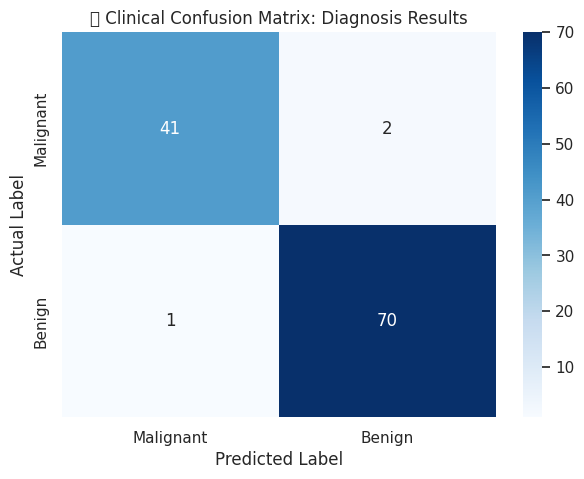

🏆 Final Clinical Accuracy: 97.4%


In [17]:
# Combining all best practices: Scaling + Adam + L2 + Early Stopping
final_model = MLPClassifier(hidden_layer_sizes=(64, 32), solver='adam', alpha=0.01,
                            early_stopping=True, random_state=42).fit(X_train_scaled, y_train)

y_pred = final_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred)

# Aesthetic Confusion Matrix
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Malignant', 'Benign'], yticklabels=['Malignant', 'Benign'])
plt.title('🩺 Clinical Confusion Matrix: Diagnosis Results')
plt.xlabel('Predicted Label'); plt.ylabel('Actual Label'); plt.show()

print(f"🏆 Final Clinical Accuracy: {accuracy_score(y_test, y_pred)*100:.1f}%")

## 📝 Summary Table

| Concept | Best Practice | Goal |
| :--- | :--- | :--- |
| **Scaling** | `StandardScaler` | Fair weightage to all features |
| **Optimiser** | **Adam** | Speed + Smart adaptability |
| **Initialisation** | **He / Xavier** | Stable gradients from start |
| **Regularisation** | **L2 Penalty + Early Stopping** | Stop memorizing, start understanding |

---

## 🎯 Day 2 Mini-Challenge
1. **The Size Test:** Change `hidden_layer_sizes` to `(128, 64, 32)`. Accuracy up or down?
2. **The Penalty Test:** Change `alpha` to `5.0`. Does the model become too "lazy"?

🔜 **Next Up:** How AI "sees" pixels — Introduction to **CNNs**!